# Signal and contrast panels

This notebook is one of 5 focused notebooks split out of the original `esmrmb_variant_comparison.ipynb` (archived under `_archive/`) so each analysis stage can be opened and run on its own. No analysis or plotting logic changed in the split -- every cell below is copied verbatim from the original notebook; only the output path gained a `resample-ogse_rest_rician` segment naming the resampling model used (`build_resampled_contrasts`, fit with `M_ogse_rest_rician`), so a future alternative resampling model can sit alongside this one without collisions.

The sibling notebooks are: `signal_and_contrast_panels.ipynb`, `contrast_vs_lcf_panels.ipynb`, `dataset_metrics.ipynb`, `contrast_models_overlap.ipynb`, `cross_dataset_metrics.ipynb`.

## 1. Imports, provenance, and data model

Run the notebook from any directory inside the project. The helper below finds the project root without relying on a user-specific absolute path. All scientific calculations are implemented in `src/presentation_analysis/abstract_figures.py`; the notebook supplies configuration, displays intermediate QC, and exports reproducible artifacts.

The long master table is the source of truth. A signal row is identified by acquisition metadata (`subj`, `sheet`, $T_D$, $N$, source file and gradient step), spatial metadata (`roi`, rotated `direction`), statistic (`avg` or `std`), and processing provenance (`variant`, `analysis_tag`, `row_kind`). `signal_rotated` means the diffusion tensor and signal directions have already been expressed relative to the local ROI/fiber frame. The analysis never infers missing rows and never merges subjects or acquisition sheets.

Main units used below: $T_D$, $\tau_c$, $\tau_f$, $c$, and $\delta$ are in ms; gradient strength is in mT/m; $D_0$ is stored in m$^2$/ms; and the Capiglioni filter length $l_{cf}=\sqrt{D_0\tau_f}$ is displayed in $\mu$m. Normalized signal and contrast are dimensionless.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'Data-BIDS').is_dir() and (candidate / 'repos' / 'signal_analysis').is_dir():
            return candidate
    raise FileNotFoundError('Could not find the Project-Balseiro-Microstructure root.')


PROJECT_ROOT = find_project_root()
REPO_ROOT = PROJECT_ROOT / 'repos' / 'signal_analysis'
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

# Reload local helpers so Run All also picks up code changes in an existing kernel.
import presentation_analysis.abstract_figures as _abstract_figures
import presentation_analysis as _presentation_analysis
importlib.reload(_abstract_figures)
importlib.reload(_presentation_analysis)

from presentation_analysis import (
    CC_ROIS,
    aggregate_alpha,
    build_resampled_contrasts,
    compare_with_reference,
    compare_with_reference_metrics,
    discover_analysis_runs,
    export_all_contrast_lcf_panels,
    export_all_signal_contrast_panels,
    fit_tc_pseudohuber,
    load_alpha_summaries,
    load_masters,
    master_qc_summary,
    merge_alpha_delta,
    normalize_alpha_to_internal_reference,
    plot_alpha_delta_scatter,
    plot_contrast_lcf_grid,
    plot_metric_comparison,
    plot_signal_contrast_example,
    save_figure_formats,
    summarize_contrast_shape,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 80)
PROJECT_ROOT

PosixPath('/mnt/c/Users/ignacio/docs/GitHub/Project-Balseiro-Microstructure')

## 2. Configuration

The first lines under **Quick selection** are normally the only ones that need editing. Choose `DATASET = 'brains'` or `DATASET = 'phantoms'`, then set `SUBJECTS_OVERRIDE`, `ROI_OVERRIDE`, and `DIRECTION_OVERRIDE`. Use a Python list even for one value, for example `['20220610P']`, `['fiber1']`, or `['long']`; use `None` to include every value allowed by the dataset profile. `SHEETS_OVERRIDE` can isolate an acquisition when one subject has several sheets.

For phantoms, selecting exactly one known subject also selects its processed source automatically: `20220610P` uses `den_gr--manual`, whereas `20260706P` uses `den_gr-topup--manual`. `DWI_LEVEL_OVERRIDE` is therefore normally left as `None`. `EXAMPLE_*` and `EXAMPLE_TD_MS` change only the detailed example panels; they do not filter the complete analysis. `VARIANTS = None` discovers current and future ROI variants automatically.

The reference diffusivity $D_0$ is a physical prior used by the restricted-signal model and by the gradient-to-length transformation; it is not refitted independently for every ROI in this notebook. Consequently, brain and phantom values must remain explicit and should be reviewed before the phantom analysis is finalized. The $N=8$ and $N=4$ selection defines the two encoding waveforms whose difference is studied. `GRADIENT_COLUMN = 'g'` is the project default because it preserves the recorded, non-equally-spaced b-value sampling; use `g_thorsten` only for an explicit legacy sensitivity analysis.

`SAVE_OUTPUTS` controls persistent tables and presentation figures. Every saved figure is written in both PNG and PDF. `EXPORT_ALL_SIGNAL_CONTRAST_PANELS` controls the exhaustive Section 6 gallery. `EXPORT_ALL_CONTRAST_LCF_PANELS` creates a Figure-02-style image for every selected subject and ROI, with directions in columns and every available $T_D$ as a colored curve. Both are enabled by default.

In [2]:
# -----------------------------------------------------------------------------
# QUICK SELECTION: edit this block first, then use Kernel > Restart & Run All.
# -----------------------------------------------------------------------------
DATASET = 'brains'  # 'brains' or 'phantoms'
#Examples: ['20220610P'], ['20260706P'], ['ADBN'], ['ADBN', 'ARVE', 'BRAIN', 'LUDG', 'MBBL', 'SNVN'], or None for all subjects
SUBJECTS_OVERRIDE = None
# Optional acquisition-sheet filter, useful when one brain subject has several scans
SHEETS_OVERRIDE = None            # e.g. ['20230623_BRAIN-4']
# Lists filter the complete analysis; None uses all defaults/available values
ROI_OVERRIDE = None               # phantom e.g. ['fiber1']; brain e.g. ['PostCC']
DIRECTION_OVERRIDE = None         # e.g. ['long'], ['tra'], or ['long', 'tra']

# One detailed signal/contrast panel (these settings do NOT filter the analysis)
EXAMPLE_SUBJECT_OVERRIDE = None   # None uses the selected subject when it is unique
EXAMPLE_ROI_OVERRIDE = None       # e.g. 'fiber1' or 'PostCC' (a string, not a list)
EXAMPLE_DIRECTION_OVERRIDE = None # e.g. 'long' or 'tra'
EXAMPLE_TD_MS = 143.4             # old phantom also has 142.5 ms; nearest value is used

# Dataset profiles: acquisition physics and default selections. Usually do not edit.
DATASET_PROFILES = {
    'brains': {
        'dwi_level': 'den_gr-topup',
        'd0_m2_ms': 3.2e-12,     # 0.0032 mm2/s
        'rois': list(CC_ROIS),
        'directions': ['long', 'tra'],
        'example_subject': 'ADBN',
        'example_roi': 'PostCC',
        'example_direction': 'long',
    },
    'phantoms': {
        'dwi_level': 'den_gr-topup',
        'd0_m2_ms': 2.3e-12,     # 0.0023 mm2/s
        'rois': None,               # None uses every ROI/sample found in the phantom master
        'directions': None,         # None prefers long/tra, then uses every available direction
        'example_subject': '20220610P',
        'example_roi': None,
        'example_direction': None,
    },
}

# Advanced data-source selection
SEQUENCE = 'ogse'
# Leave None: the notebook maps 20220610P -> den_gr and 20260706P -> den_gr-topup.
DWI_LEVEL_OVERRIDE = None          # force only when auditing a specific processing level
VARIANTS = ['plain']                   # brains e.g. ['plain'] or ['plain', 'erode1', 'sket1']
REFERENCE_VARIANT = None           # None prefers plain; phantoms use manual

# Contrast definition from the abstract
N_HIGH = 8
N_LOW = 4
# Use the gradient derived from each recorded b-value. This preserves non-equally-spaced
# acquisitions such as ADBN, ARVE, SNVN, and 20260706P. Set 'g_thorsten' only to
# reproduce the legacy equally-spaced-axis analysis.
GRADIENT_COLUMN = 'g'
APPLY_GRADIENT_CORRECTION = True
RESAMPLE_GRID_SIZE = 1000
SIGNAL_TC_BOUNDS_MS = (0.1, 10000.0)
RICIAN_C_BOUNDS = (0.0, 2.0)
SIGNAL_TC_MODE = 'separate'         # Flexible curve construction; not a physical two-tc interpretation

# Example-panel display limits
LCF_LIMITS_UM = (2.5, 11.0)  # Historical Capiglioni/abstract axis
TD_COLOR_TOLERANCE_MS = 8.0  # Includes both historical and current acquisition times

# Pseudo-Huber configuration used in the abstract analysis
EXCLUDE_TD_MS = (76.0,)
TD_RANGE_MS = (50.0, 250.0)
C_BOUNDS_MS = (0.0, 10.0)
DELTA_BOUNDS_MS = (1e-6, 10000.0)

# Transparent display-only QC. All fits remain in the exported audit tables.
MIN_PSEUDOHUBER_R2_FOR_SUMMARY = 0.50
EXCLUDE_DELTA_BOUNDARY_FROM_SUMMARY = True

# Exhaustive Section 6 export: one panel per subject/sheet/ROI/direction/TD combination.
EXPORT_ALL_SIGNAL_CONTRAST_PANELS = True
# Figure-02 gallery: one contrast-vs-filtered-length image per subject and ROI.
EXPORT_ALL_CONTRAST_LCF_PANELS = True
CLEAN_BATCH_PANEL_DIR = True       # Remove stale PNG/PDF files and the manifest inside each gallery
BATCH_PANEL_DPI = 180             # Lower than the presentation figures to control disk usage
BATCH_PROGRESS_EVERY = 25

SAVE_OUTPUTS = True

# Known phantom subjects use different processed derivatives.
PHANTOM_DWI_LEVEL_BY_SUBJECT = {
    '20220610P': 'den_gr',
    '20260706P': 'den_gr-topup',
}

def selection_list(value):
    if value is None:
        return None
    return [value] if isinstance(value, str) else list(value)

SELECTED_SUBJECTS = selection_list(SUBJECTS_OVERRIDE)
SELECTED_SHEETS = selection_list(SHEETS_OVERRIDE)
if DATASET not in DATASET_PROFILES:
    raise ValueError(f'Unknown DATASET={DATASET!r}; choose one of {list(DATASET_PROFILES)}.')
PROFILE = DATASET_PROFILES[DATASET]
if DWI_LEVEL_OVERRIDE is not None:
    DWI_LEVEL = DWI_LEVEL_OVERRIDE
elif DATASET == 'phantoms' and SELECTED_SUBJECTS is not None and len(SELECTED_SUBJECTS) == 1:
    DWI_LEVEL = PHANTOM_DWI_LEVEL_BY_SUBJECT.get(SELECTED_SUBJECTS[0], PROFILE['dwi_level'])
else:
    DWI_LEVEL = PROFILE['dwi_level']
D0_REFERENCE_M2_MS = PROFILE['d0_m2_ms']
VARIANTS_DIRNAME = 'all' if VARIANTS is None else '+'.join(selection_list(VARIANTS))
OUTPUT_DIR = (
    REPO_ROOT / 'notebooks' / 'outputs' / 'signal_and_contrast_panels' / 'resample-ogse_rest_rician'
    / DATASET / DWI_LEVEL / VARIANTS_DIRNAME
)
OUTPUT_DIR

PosixPath('/mnt/c/Users/ignacio/docs/GitHub/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/signal_and_contrast_panels/resample-ogse_rest_rician/brains/den_gr-topup/plain')

## 3. Discover variants and audit comparability

The analysis tag is parsed as `<DWI level>--<ROI variant>`. Newly created variants appear automatically when `VARIANTS` is `None`. Every table is loaded with its variant and dataset provenance attached before concatenation.

For the current corpus-callosum analysis, `plain` is the original labeled CC mask, `erode1` erodes the whole CC by one voxel and then restores the surviving original labels, and `sket1` is the CC skeleton dilated by one voxel and clipped to the original CC. Erosion reduces boundary partial volume but can delete thin subregions; the skeletonized band emphasizes the medial core but samples fewer and spatially different voxels. Therefore agreement across variants supports robustness to ROI geometry, whereas disagreement can reflect partial volume, SNR/voxel-count changes, or true spatial heterogeneity—it is not automatically an error in one method. Future variant names are treated as new provenance levels; their biological interpretation must come from the segmentation procedure that created them.

A fair segmentation comparison requires more than a similar total row count. Coverage is therefore compared on the complete logical signal key. `missing_rows` reports reference observations that cannot be matched in a candidate variant, while `extra_rows` reports the reverse. A missing ROI can be a legitimate consequence of erosion or skeletonization, but it reduces the paired sample and must remain visible. Exact or logical duplicates indicate an ingestion problem and should be resolved upstream.

Later group summaries use only matched subject/ROI/direction keys. No signal, fit, ROI, or subject is imputed to make variants appear balanced.

In [3]:
runs = discover_analysis_runs(
    PROJECT_ROOT,
    dataset=DATASET,
    sequence=SEQUENCE,
    dwi_level=DWI_LEVEL,
)
available_variants = runs['variant'].tolist()
if VARIANTS is None:
    preferred_order = ['plain', 'erode1', 'sket1']
    selected_variants = [v for v in preferred_order if v in available_variants]
    selected_variants += [v for v in available_variants if v not in selected_variants]
else:
    selected_variants = list(VARIANTS)
if REFERENCE_VARIANT is None:
    REFERENCE_VARIANT = 'plain' if 'plain' in selected_variants else selected_variants[0]
if REFERENCE_VARIANT not in selected_variants:
    raise ValueError(f'Reference variant {REFERENCE_VARIANT!r} is not selected.')

display(runs[['dwi_level', 'variant', 'dataset', 'master_path']])
print('Selected variants:', selected_variants)

,dwi_level,variant,dataset,master_path
0,den_gr-topup,erode1,brains,/mnt/c/Users/ignacio/docs/GitHub/Project-Balse...
1,den_gr-topup,plain,brains,/mnt/c/Users/ignacio/docs/GitHub/Project-Balse...
2,den_gr-topup,sket1,brains,/mnt/c/Users/ignacio/docs/GitHub/Project-Balse...


Selected variants: ['plain']


In [4]:
masters = load_masters(runs, selected_variants)
alpha_raw = load_alpha_summaries(
    runs, selected_variants, reference_d0_m2_ms=D0_REFERENCE_M2_MS
)

# Filter complete tables, not only the example plot. Fail early on misspelled values.
for column, requested in [('subj', SELECTED_SUBJECTS), ('sheet', SELECTED_SHEETS)]:
    if requested is None:
        continue
    available = sorted(masters[column].dropna().astype(str).unique())
    missing = sorted(set(requested) - set(available))
    if missing:
        raise ValueError(
            f'{column} selection {missing} is unavailable for DATASET={DATASET!r}, '
            f'DWI_LEVEL={DWI_LEVEL!r}. Available values: {available}'
        )
    masters = masters[masters[column].astype(str).isin(requested)].copy()
    if column in alpha_raw.columns:
        alpha_raw = alpha_raw[alpha_raw[column].astype(str).isin(requested)].copy()
alpha_subject = aggregate_alpha(alpha_raw)

# Resolve analysis dimensions from the profile and the loaded master table.
rotated = masters.loc[masters['row_kind'].eq('signal_rotated')].copy()
available_subjects = sorted(rotated['subj'].dropna().astype(str).unique())
available_sheets = sorted(rotated['sheet'].dropna().astype(str).unique())
available_rois = sorted(rotated['roi'].dropna().astype(str).unique())
available_directions = sorted(rotated['direction'].dropna().astype(str).unique())
available_td_ms = sorted(pd.to_numeric(rotated['td_ms'], errors='coerce').dropna().unique())
requested_rois = ROI_OVERRIDE if ROI_OVERRIDE is not None else PROFILE['rois']
requested_directions = (
    DIRECTION_OVERRIDE if DIRECTION_OVERRIDE is not None else PROFILE['directions']
)
analysis_rois = (
    available_rois
    if requested_rois is None
    else [roi for roi in requested_rois if roi in available_rois]
)
if requested_directions is None:
    preferred_directions = [d for d in ['long', 'tra'] if d in available_directions]
    analysis_directions = preferred_directions or available_directions
else:
    analysis_directions = [d for d in requested_directions if d in available_directions]
if not analysis_rois or not analysis_directions:
    raise ValueError(
        f'No usable dimensions. Available ROIs={available_rois}; directions={available_directions}.'
    )

profile_example_subject = PROFILE['example_subject']
profile_example_roi = PROFILE['example_roi']
profile_example_direction = PROFILE['example_direction']
EXAMPLE_SUBJECT = (
    EXAMPLE_SUBJECT_OVERRIDE
    or (SELECTED_SUBJECTS[0] if SELECTED_SUBJECTS is not None and len(SELECTED_SUBJECTS) == 1 else None)
    or (profile_example_subject if profile_example_subject in available_subjects else None)
)
EXAMPLE_ROI = (
    EXAMPLE_ROI_OVERRIDE
    or (profile_example_roi if profile_example_roi in available_rois else None)
)
EXAMPLE_DIRECTION = (
    EXAMPLE_DIRECTION_OVERRIDE
    or (profile_example_direction if profile_example_direction in available_directions else None)
)

qc = master_qc_summary(masters)
coverage, missing_rows = compare_with_reference(
    masters,
    reference_variant=REFERENCE_VARIANT,
    row_kind='signal_rotated',
)
display(qc)
display(coverage)
print('Subjects:', available_subjects)
print('Sheets:', available_sheets)
print('Analysis ROIs:', analysis_rois)
print('Analysis directions:', analysis_directions)
print('Diffusion times [ms]:', available_td_ms)
print(
    'Requested example:',
    EXAMPLE_SUBJECT or 'auto',
    EXAMPLE_ROI or 'auto',
    EXAMPLE_DIRECTION or 'auto',
    EXAMPLE_TD_MS,
)

,variant,rows,signal_rows,rotated_rows,subjects,sheets,sources,exact_duplicates,logical_duplicates
0,plain,275520,217920,57600,6,10,92,0,0


,variant,reference,reference_rows,matched_rows,missing_rows,extra_rows,coverage_percent
0,plain,plain,57600,57600,0,0,100.0


Subjects: ['ADBN', 'ARVE', 'BRAIN', 'LUDG', 'MBBL', 'SNVN']
Sheets: ['20220622_BRAIN', '20230619_BRAIN-3', '20230623_BRAIN-4', '20230623_LUDG-2', '20230629_MBBL-2', '20230630_MBBL-3', '20230710_LUDG-3', '20260710_ADBN-1', '20260710_ARVE-1', '20260710_SNVN-1']
Analysis ROIs: ['AntCC', 'MidAntCC', 'CentralCC', 'MidPostCC', 'PostCC']
Analysis directions: ['long', 'tra']
Diffusion times [ms]: [np.float64(76.0), np.float64(90.0), np.float64(120.0), np.float64(143.4), np.float64(210.0)]
Requested example: ADBN PostCC long 143.4


## 4. Gradient correction, signal fitting, resampling, and contrast

### 4.1 Why the gradient axis must be corrected first

The nominal gradient is not assumed to be the physical gradient experienced by the sample. Upstream calibration uses a reference ROI and computes

$$f_g=\sqrt{D_{0,\mathrm{NOGSE}}/\langle D_{0,\mathrm{monoexp}}\rangle}, \qquad g_{corr}=f_g g_{nominal}.$$

The factor may depend on acquisition, direction, and $N$. It is already stored in each master row as `grad_correction_factor`; this notebook applies it but does not estimate it again. Because the corrected $N=8$ and $N=4$ gradient samples generally do not coincide, subtracting rows with the same acquisition index would evaluate the two signals at different physical gradients and would not define $\Delta M(g)$ at a common $g$.

### 4.2 Restricted signal and normalized Rician floor

For each subject/sheet/ROI/direction/$T_D$ group, the two branches are fitted jointly. The clean restricted model can be summarized as

$$M_{rest}=M_0\exp[-\phi_{SE}-\phi_N+\phi_{cross}],$$

where the attenuation terms encode the finite correlation time $\tau_c$, waveform timing, $N$, corrected gradient, and fixed $D_0$. Here the waveform interval is $x=T_D/N$. Magnitude-MRI noise produces a non-zero floor, represented by

$$M(g,N,T_D)=\frac{\sqrt{M_{rest}(g,N,T_D)^2+C^2}}{\sqrt{1+C^2}}.$$

The denominator preserves $M(0)=1$ for normalized data. The fit has three free parameters: $\tau_{c,8}$, $\tau_{c,4}$, and one shared $C$. It fixes $M_0=1$ and the dataset-specific $D_0$. Sharing $C$ treats the two branches as measurements with a common magnitude-noise floor while allowing their effective correlation times to differ. The optimizer works in log space for positive $\tau_c$ values and reports branch-specific and combined $R^2$, RMSE, parameter errors, bounds, and status in `signal_pair_fit_summary.csv`.

### 4.3 Common-grid resampling

After fitting, both continuous models are evaluated on the same grid

$$g_j\in[0,\min(g_{8,max}^{corr},g_{4,max}^{corr})], \qquad j=1,\ldots,n_g,$$

and the contrast is finally computed as

$$\Delta M_{fit}(g_j)=M_{8,fit}(g_j)-M_{4,fit}(g_j).$$

Using only the overlap prevents the peak from being driven by extrapolation beyond one branch's measured range. The grid begins at zero, so both normalized fits equal one and $\Delta M_{fit}(0)=0$ by construction. `RESAMPLE_GRID_SIZE` controls numerical peak resolution; it does not add independent observations.

### 4.4 From the contrast peak to a filtered length and time

The sampled maximum gives $g_{peak}$. With $\gamma=267.5221900$ rad ms$^{-1}$ mT$^{-1}$ and the fixed $D_0$, the notebook uses the historical definition published by Capiglioni et al. (2021):

$$l_G=\left(\frac{D_0}{\gamma g}\right)^{1/3}, \quad l_D=\sqrt{D_0T_D}, \quad L_D=\frac{l_D}{l_G},$$

$$L_{cf}=\left(\frac{3}{2}\right)^{1/4}L_D^{-1/2}, \quad l_{cf}=L_{cf}l_G=\left(\frac{3D_0}{2\gamma^2g^2T_D}\right)^{1/4}, \quad \tau_{f,\mathrm{peak}}=\frac{l_{cf}^2}{D_0}.$$

This is the same physical-length convention used by the historical abstract figures. The alternative one-dimensional RMS displacement $\sqrt{2D_0\tau_f}$ is exactly $\sqrt{2}$ larger and is not used on these axes. These are model-derived coordinates, not independently measured histological sizes. Their interpretation inherits the assumptions of the restricted model, the chosen $D_0$, the gradient calibration, and the peak-selection rule.

In [5]:
contrasts, contrast_fits = build_resampled_contrasts(
    masters,
    d0_m2_ms=D0_REFERENCE_M2_MS,
    n_high=N_HIGH,
    n_low=N_LOW,
    directions=analysis_directions,
    rois=analysis_rois,
    gradient_column=GRADIENT_COLUMN,
    apply_gradient_correction=APPLY_GRADIENT_CORRECTION,
    tc_bounds_ms=SIGNAL_TC_BOUNDS_MS,
    rician_c_bounds=RICIAN_C_BOUNDS,
    grid_size=RESAMPLE_GRID_SIZE,
    tc_mode=SIGNAL_TC_MODE,
)
contrast_shape = summarize_contrast_shape(contrasts)

contrast_fit_qc = (
    contrast_fits.groupby(['variant', 'ok'], as_index=False)
    .agg(curves=('td_ms', 'size'), median_r2=('r2', 'median'), median_rmse=('rmse', 'median'))
)
display(contrast_fit_qc)
display(
    contrast_fits.loc[contrast_fits['ok'].fillna(False)]
    .nsmallest(15, 'r2')[
        ['variant', 'subj', 'roi', 'direction', 'td_ms', 'r2_high', 'r2_low', 'r2', 'C']
    ]
)
print(f'Resampled contrast points: {len(contrasts):,}')
print(f'Signal pairs: {len(contrast_fits):,}; successful: {int(contrast_fits.ok.sum()):,}')

,variant,ok,curves,median_r2,median_rmse
0,plain,True,250,0.994655,0.019428


,variant,subj,roi,direction,td_ms,r2_high,r2_low,r2,C
116,plain,BRAIN,MidPostCC,tra,76.0,0.214527,0.981355,0.900669,0.632330
71,plain,ARVE,AntCC,long,210.0,0.947632,0.917601,0.935715,0.347719
176,plain,MBBL,MidPostCC,tra,120.0,0.947016,0.929703,0.954103,0.265974
112,plain,BRAIN,CentralCC,tra,76.0,0.766335,0.983609,0.956566,0.707477
243,plain,SNVN,CentralCC,long,210.0,0.945375,0.979754,0.960894,0.268314
117,plain,BRAIN,MidPostCC,long,76.0,0.623549,0.988458,0.962818,0.354177
177,plain,MBBL,MidPostCC,long,120.0,0.959708,0.955679,0.968665,0.143787
73,plain,ARVE,CentralCC,long,210.0,0.985734,0.953843,0.970536,0.237276
126,plain,BRAIN,MidPostCC,tra,210.0,0.973356,0.967461,0.973270,0.360091
136,plain,LUDG,MidPostCC,tra,120.0,0.979558,0.969693,0.974038,0.295558


Resampled contrast points: 250,000
Signal pairs: 250; successful: 250


## 6. Figure 1b analogue: paired signal fits and resampled contrast

Each row is one ROI-extraction variant. In the left column, markers are the measured $N=8$ and $N=4$ normalized signals plotted at their own corrected gradients; solid lines are the simultaneous restricted-model fits with a shared Rician $C$. The data points need not share x-coordinates. In the right column, the green curve is the difference of those fitted signals after evaluation on one common corrected-gradient grid; the star marks its sampled maximum.

This visual is the most direct diagnostic of the analysis chain. Check that both branches cover a useful gradient range, that the fitted lines follow the measurements without a bound-driven shape, that the contrast starts at zero, and that the peak lies inside the shared range rather than at its boundary. A blank variant row means that this exact acquisition combination was missing or its paired fit failed; it is deliberately not hidden.

The first cell below keeps one convenient interactive example. The next cell exports the same two-column comparison for **every** subject, acquisition sheet, ROI, direction, and diffusion time found in the fit audit.

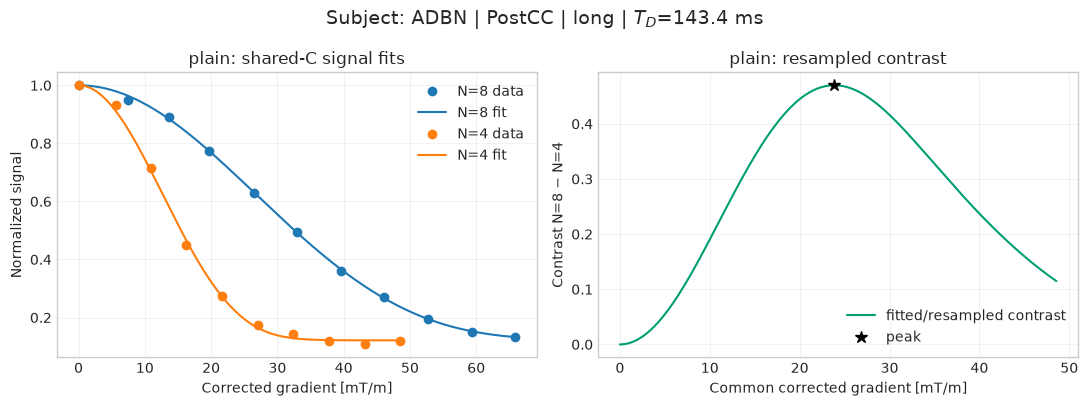

Exported 25/250 signal/contrast panels
Exported 50/250 signal/contrast panels
Exported 75/250 signal/contrast panels
Exported 100/250 signal/contrast panels
Exported 125/250 signal/contrast panels
Exported 150/250 signal/contrast panels
Exported 175/250 signal/contrast panels
Exported 200/250 signal/contrast panels
Exported 225/250 signal/contrast panels
Exported 250/250 signal/contrast panels


,subj,all_selected_variants_successful,panels
0,ADBN,True,40
1,ARVE,True,40
2,BRAIN,True,50
3,LUDG,True,40
4,MBBL,True,40
5,SNVN,True,40


Exhaustive Section 6 gallery: /mnt/c/Users/ignacio/docs/GitHub/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/signal_and_contrast_panels/resample-ogse_rest_rician/brains/den_gr-topup/plain/06_all_signal_contrast_panels
Gallery panels: 250


In [6]:
figure_1b = plot_signal_contrast_example(
    masters,
    contrasts,
    contrast_fits,
    variants=selected_variants,
    subject=EXAMPLE_SUBJECT,
    roi=EXAMPLE_ROI,
    direction=EXAMPLE_DIRECTION,
    td_ms=EXAMPLE_TD_MS,
    n_high=N_HIGH,
    n_low=N_LOW,
    gradient_column=GRADIENT_COLUMN,
    output_path=OUTPUT_DIR / '01_signal_and_contrast.png' if SAVE_OUTPUTS else None,
)
plt.show()

all_panel_manifest = pd.DataFrame()
if SAVE_OUTPUTS and EXPORT_ALL_SIGNAL_CONTRAST_PANELS:
    all_panel_dir = OUTPUT_DIR / '06_all_signal_contrast_panels'
    all_panel_manifest = export_all_signal_contrast_panels(
        masters,
        contrasts,
        contrast_fits,
        variants=selected_variants,
        output_dir=all_panel_dir,
        n_high=N_HIGH,
        n_low=N_LOW,
        gradient_column=GRADIENT_COLUMN,
        dpi=BATCH_PANEL_DPI,
        progress_every=BATCH_PROGRESS_EVERY,
        clean_output=CLEAN_BATCH_PANEL_DIR,
    )
    display(
        all_panel_manifest.groupby(
            ['subj', 'all_selected_variants_successful'], as_index=False
        ).size().rename(columns={'size': 'panels'})
    )
    print(f'Exhaustive Section 6 gallery: {all_panel_dir}')
    print(f'Gallery panels: {len(all_panel_manifest):,}')

## Output map

`01_signal_and_contrast.{png,pdf}` is the one interactive example panel (`EXAMPLE_SUBJECT`/`EXAMPLE_ROI`/`EXAMPLE_DIRECTION`/`EXAMPLE_TD_MS`). `06_all_signal_contrast_panels/` is the exhaustive gallery: one two-column image (left: per-branch signal fits; right: resampled contrast) per subject, sheet, ROI, direction, and diffusion time, with every selected ROI variant as a row and a `manifest.csv` index:

```text
06_all_signal_contrast_panels/
├── manifest.csv
└── sub-<subject>/
    └── sheet-<acquisition>/
        ├── roi-<ROI>__dir-<direction>__td-<time>ms.png
        └── roi-<ROI>__dir-<direction>__td-<time>ms.pdf
```

Check that both branches cover a useful gradient range, that the fitted lines follow the measurements without a bound-driven shape, that the contrast starts at zero, and that the peak lies inside the shared range rather than at its boundary.